In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
# ── Step 1: Define Dataset Paths ─────────────────────────────────────────────
# Images are organised as: path/class_name/image.jpg
train_path = "Practice/plant_disease/train"
valid_path = "Practice/plant_disease/valid"
test_path  = "Practice/plant_disease/test"

In [6]:
# ── Step 2: Image Preprocessing (Data Augmentation) ──────────────────────────
# Training: augment images so the model sees more variety → less overfitting
#   rescale: pixel values 0-255 → 0-1 (normalise)
#   rotation_range, zoom_range, horizontal_flip: random transformations
# Validation/Test: only rescale, NO augmentation (we want real performance numbers)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [19]:
# ── Step 3: Load Images from Folders ─────────────────────────────────────────
# flow_from_directory: reads images from subfolders, resizes to 128×128
# class_mode='categorical': one-hot encodes labels for multi-class classification
# test: class_mode=None + shuffle=False → predictions stay in order
train_data = train_datagen.flow_from_directory(
    train_path, target_size=(128, 128), batch_size=32, class_mode='categorical'
)
valid_data = valid_datagen.flow_from_directory(
    valid_path, target_size=(128, 128), batch_size=32, class_mode='categorical'
)
test_data = test_datagen.flow_from_directory(
    test_path, target_size=(128, 128), batch_size=16, class_mode=None, shuffle=False
)

Found 22263 images belonging to 38 classes.
Found 3648 images belonging to 38 classes.
Found 33 images belonging to 1 classes.


In [8]:
# ── Step 4: Inspect Class Labels ─────────────────────────────────────────────
# 38 classes: each is a plant species + disease (or healthy)
print("Number of classes:", train_data.num_classes)
print("\nClass Labels:")
print(train_data.class_indices)

Number of classes: 38

Class Labels:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29

In [9]:
# ── Step 5: Build CNN — Convolutional Blocks ─────────────────────────────────
# Each block: Conv2D (detect features) → MaxPooling (reduce size) → Dropout (regularise)
# Filters double each block (32 → 64 → 128): learns increasingly complex features
model = Sequential()

# Block 1: detects simple edges and textures
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 2: detects shapes and patterns
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 3: detects high-level disease features
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

/Users/froncort.ai/Desktop/LP_5/lp5/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# ── Step 5 (cont): Classifier Head ───────────────────────────────────────────
# Flatten: converts 3D feature maps → 1D vector for Dense layers
# Dense(128): fully connected layer to combine all features
# Dropout(0.5): aggressive regularisation before the final classification
# softmax: outputs a probability for each of the 38 classes (sum = 1)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation='softmax'))

In [11]:
# ── Step 6: Compile ───────────────────────────────────────────────────────────
# categorical_crossentropy: correct loss for multi-class with softmax output
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ── Step 7: Train ────────────────────────────────────────────────────────────
# validation_data: uses a separate generator (not a split) for honest validation
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 91s 130ms/step - accuracy: 0.4020 - loss: 1.8065 - val_accuracy: 0.3013 - val_loss: 7.2421
Epoch 2/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 108s 155ms/step - accuracy: 0.6220 - loss: 1.1185 - val_accuracy: 0.3336 - val_loss: 9.6795
Epoch 3/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 116s 166ms/step - accuracy: 0.6929 - loss: 0.8957 - val_accuracy: 0.4043 - val_loss: 10.1151
Epoch 4/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 120s 172ms/step - accuracy: 0.7363 - loss: 0.7777 - val_accuracy: 0.4254 - val_loss: 10.0594
Epoch 5/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 118s 169ms/step - accuracy: 0.7681 - loss: 0.6868 - val_accuracy: 0.4523 - val_loss: 11.4733
Epoch 6/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 126s 181ms/step - accuracy: 0.7911 - loss: 0.6222 - val_accuracy: 0.4668 - val_loss: 13.1580
Epoch 7/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 127s 182ms/step - accuracy: 0.8071 - loss: 0.5661 - val_accuracy: 0.4380 - val_loss: 12.6091
Epoch 8/10
696/696 ━━━━━━━━━━━━━━━━━━━━ 120s 173ms/step - accuracy: 0.81

In [16]:
# ── Step 8: Save Model ────────────────────────────────────────────────────────
# .keras format is the modern Keras standard (no deprecation warnings)
model.save("plant_disease_cnn_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [17]:
# ── Step 9: Print Final Accuracy ─────────────────────────────────────────────
# [-1] gets the value from the last epoch
print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

Training Accuracy   : 0.8537
Validation Accuracy : 0.4646


In [20]:
# ── Step 10: Predict on Test Images ──────────────────────────────────────────
# argmax picks the class with the highest probability for each image
predictions     = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
class_labels    = list(train_data.class_indices.keys())

print("Predictions:")
for i, cls in enumerate(predicted_classes):
    print(f"  Image {i+1}: {class_labels[cls]}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
Predictions:
  Image 1: Apple___Cedar_apple_rust
  Image 2: Apple___Cedar_apple_rust
  Image 3: Apple___Cedar_apple_rust
  Image 4: Apple___Cedar_apple_rust
  Image 5: Apple___Cedar_apple_rust
  Image 6: Apple___healthy
  Image 7: Tomato___Late_blight
  Image 8: Tomato___Late_blight
  Image 9: Tomato___Late_blight
  Image 10: Tomato___Late_blight
  Image 11: Tomato___Septoria_leaf_spot
  Image 12: Tomato___healthy
  Image 13: Apple___healthy
  Image 14: Tomato___Septoria_leaf_spot
  Image 15: Tomato___Septoria_leaf_spot
  Image 16: Apple___Black_rot
  Image 17: Apple___Black_rot
  Image 18: Tomato___Late_blight
  Image 19: Tomato___Late_blight
  Image 20: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  Image 21: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  Image 22: Tomato___Late_blight
  Image 23: Tomato___Spider_mites Two-spotted_spider_mite
  Image 24: Tomato___healthy
  Image 25: Tomato___healthy
  Image 26: Tomato___healthy
  Image 27: Tomato___healthy


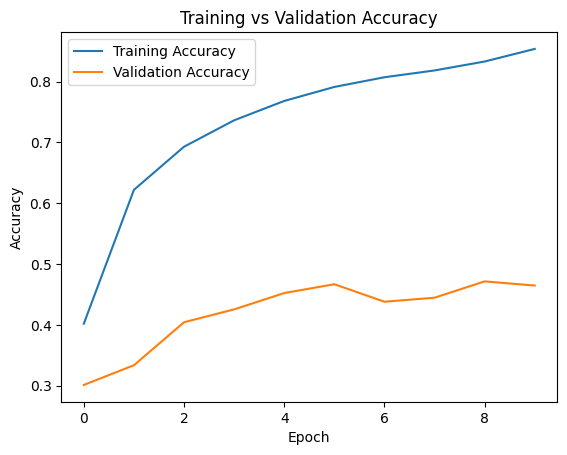

In [21]:
# ── Step 11: Plot Accuracy & Loss ────────────────────────────────────────────
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

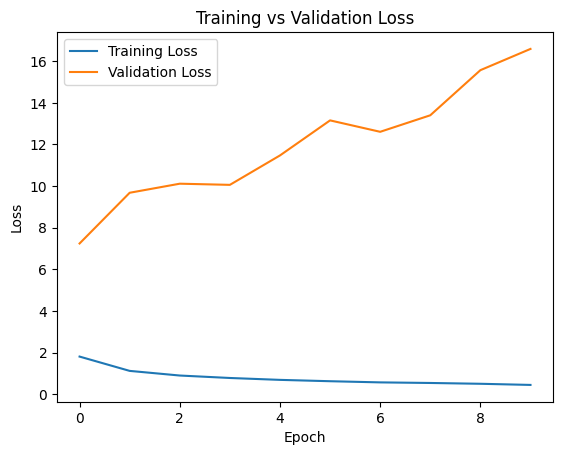

In [22]:
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()